# Seasonal ARIMA (SARIMA) in R

## Overview

SARIMA extends ARIMA to handle periodic patterns. Notation: **SARIMA(p,d,q)(P,D,Q)[m]**

| Parameter | Meaning |
|---|---|
| p, d, q | Non-seasonal AR, differencing, MA |
| P, D, Q | Seasonal AR, differencing, MA |
| m | Seasonal period (12 = monthly, 4 = quarterly, 52 = weekly) |

**Identifying seasonal terms from ACF/PACF (after d=1, D=1):**
- Spike at lag m in ACF only → seasonal MA (Q=1)
- Spike at lag m in PACF only → seasonal AR (P=1)
- Slow decay at lags m, 2m, 3m → D=1 needed

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'forecast' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version

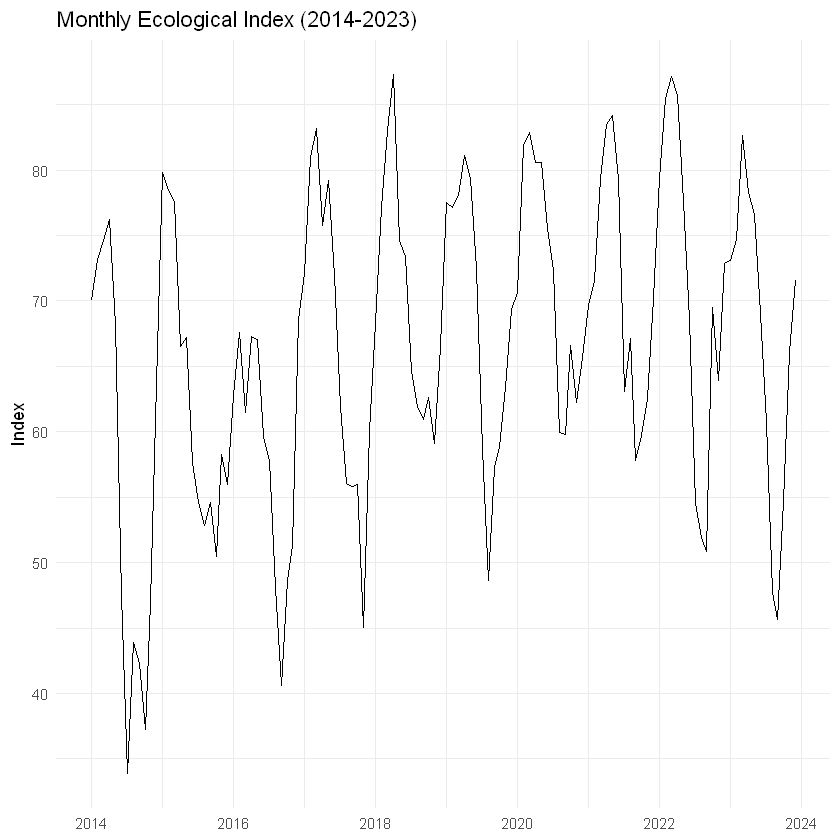

In [1]:
library(tidyverse)
library(ggplot2)
library(forecast)
library(patchwork)

set.seed(42)

# Simulate monthly data with trend + seasonality + AR noise
n <- 120
eco_monthly <- ts(
  60 + 0.12 * seq_len(n) +
  15 * sin(2 * pi * seq_len(n) / 12) +
  arima.sim(list(ar=0.55), n=n, sd=5),
  start=c(2014,1), frequency=12
)

autoplot(eco_monthly) +
  labs(title="Monthly Ecological Index (2014-2023)", x=NULL, y="Index") +
  theme_minimal()

---

## Identification: Seasonal Differencing and ACF/PACF

Regular diffs (KPSS): 1
Seasonal diffs (Canova-Hansen): 1


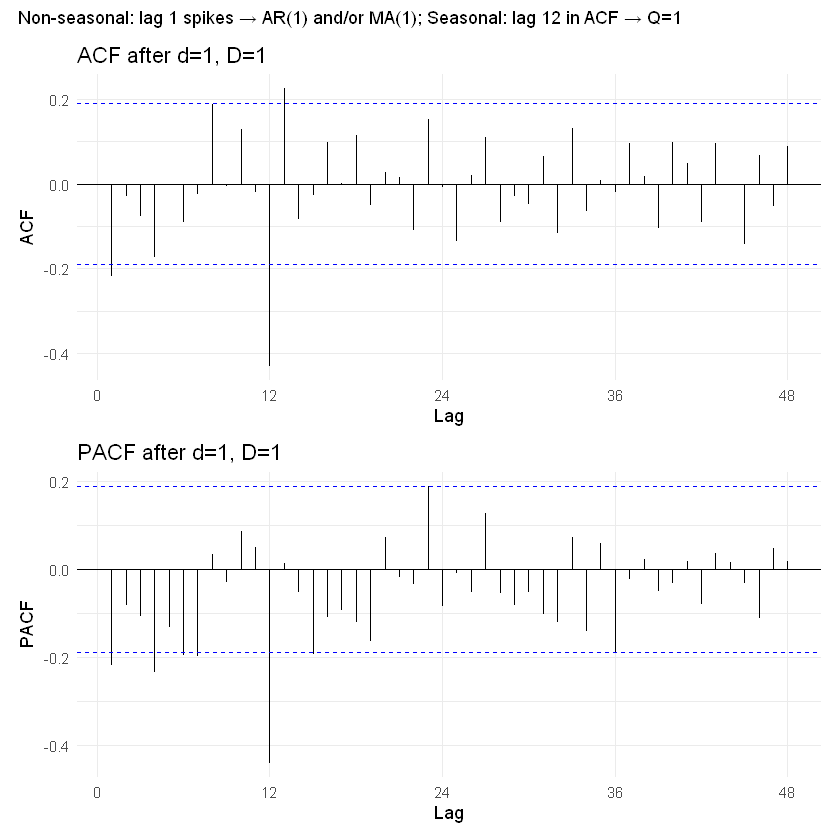

In [2]:
# How many differences needed?
cat(sprintf("Regular diffs (KPSS): %d\n",
            forecast::ndiffs(eco_monthly, test="kpss")))
cat(sprintf("Seasonal diffs (Canova-Hansen): %d\n",
            forecast::nsdiffs(eco_monthly, test="seas")))

# Apply D=1 seasonal + d=1 regular
eco_diff <- diff(diff(eco_monthly, lag=12), differences=1)

# ACF/PACF after differencing
p1 <- forecast::ggAcf(eco_diff,  lag.max=48) +
      labs(title="ACF after d=1, D=1") + theme_minimal()
p2 <- forecast::ggPacf(eco_diff, lag.max=48) +
      labs(title="PACF after d=1, D=1") + theme_minimal()
(p1 / p2) +
  patchwork::plot_annotation(
    subtitle=paste("Non-seasonal: lag 1 spikes → AR(1) and/or MA(1);",
                   "Seasonal: lag 12 in ACF → Q=1")
  )

---

## Fitting SARIMA

In [3]:
# Manual specification from ACF/PACF reading
m_manual <- forecast::Arima(
  eco_monthly,
  order    = c(1,1,1),
  seasonal = list(order=c(0,1,1), period=12)
)

# Auto selection
m_auto <- forecast::auto.arima(
  eco_monthly,
  seasonal=TRUE, stepwise=FALSE, approximation=FALSE,
  ic="aicc", max.p=3, max.q=3, max.P=2, max.Q=2
)

tibble(
  model = c("Manual SARIMA(1,1,1)(0,1,1)[12]",
            sprintf("Auto SARIMA(%d,%d,%d)(%d,%d,%d)[12]",
              m_auto$arma[1], m_auto$arma[6], m_auto$arma[2],
              m_auto$arma[3], m_auto$arma[7], m_auto$arma[4])),
  AICc  = c(m_manual$aicc, m_auto$aicc)
) %>% mutate(delta_AICc=round(AICc-min(AICc),2)) %>% print()

# A tibble: 2 × 3
  model                            AICc delta_AICc
  <chr>                           <dbl>      <dbl>
1 Manual SARIMA(1,1,1)(0,1,1)[12]  691.       0   
2 Auto SARIMA(1,0,0)(0,1,1)[12]    693.       1.16


---

## Diagnostics


	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(0,1,1)[12] with drift
Q* = 16.81, df = 22, p-value = 0.7737

Model df: 2.   Total lags used: 24

Ljung-Box (lag 24): Q=16.810, p=0.7737


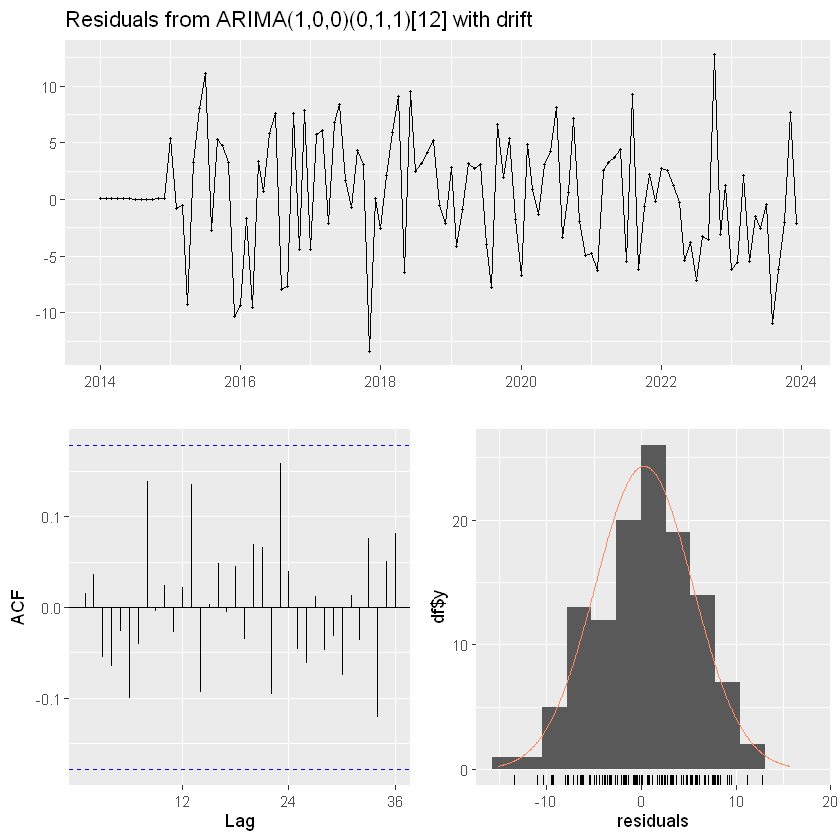

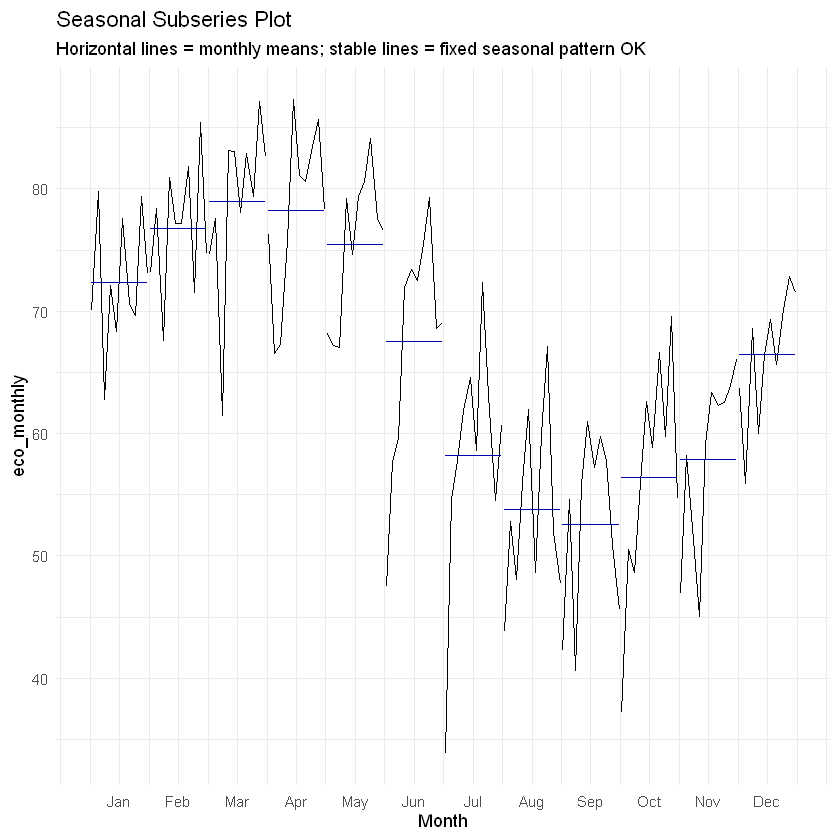

In [4]:
forecast::checkresiduals(m_auto)

# Ljung-Box at lag 24 (2 × seasonal period) for seasonal adequacy
n_par <- sum(m_auto$arma[1:4])
lb <- Box.test(residuals(m_auto), lag=24, type="Ljung-Box", fitdf=n_par)
cat(sprintf("Ljung-Box (lag 24): Q=%.3f, p=%.4f\n", lb$statistic, lb$p.value))

# Seasonal subseries plot: does the seasonal pattern look stable?
forecast::ggsubseriesplot(eco_monthly) +
  labs(title="Seasonal Subseries Plot",
       subtitle="Horizontal lines = monthly means; stable lines = fixed seasonal pattern OK") +
  theme_minimal()

---

## Forecasting

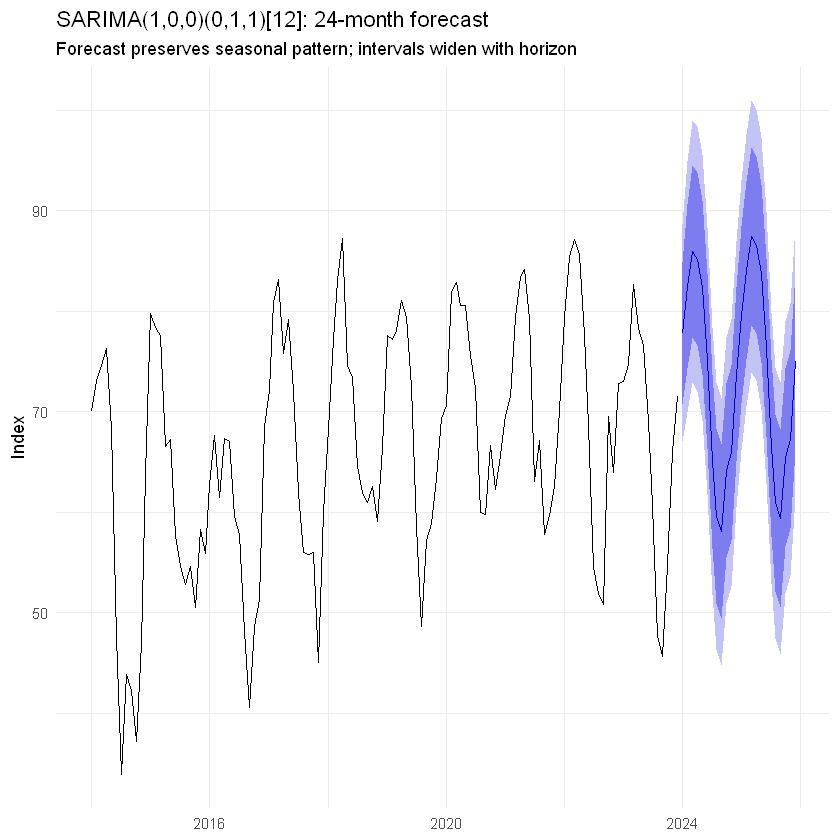

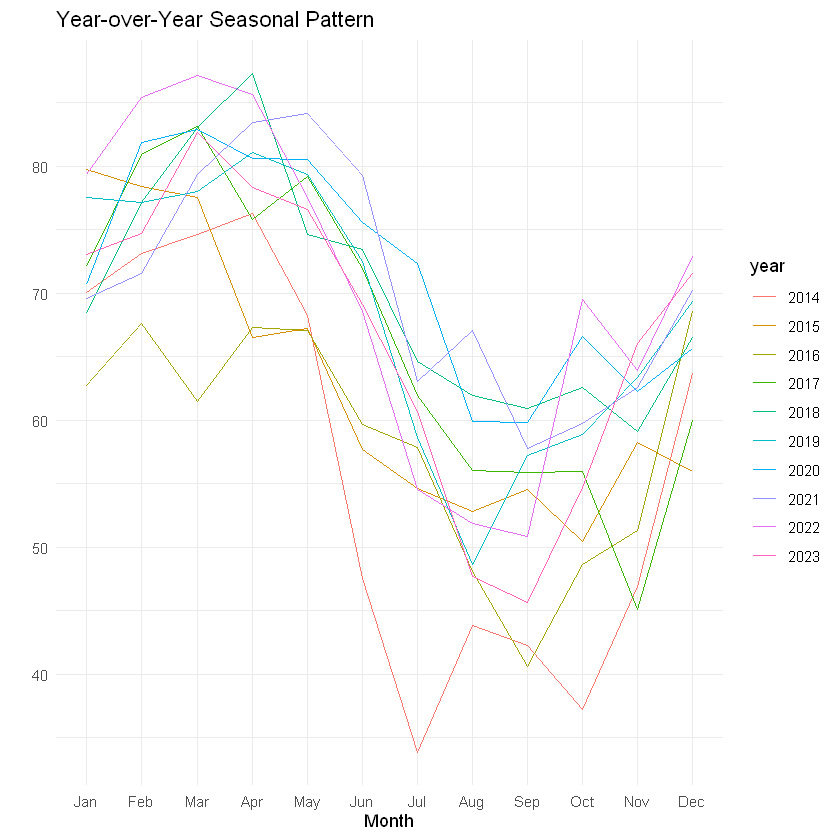

In [5]:
fc <- forecast::forecast(m_auto, h=24, level=c(80,95))

autoplot(fc) +
  labs(
    title=sprintf("SARIMA(%d,%d,%d)(%d,%d,%d)[12]: 24-month forecast",
      m_auto$arma[1], m_auto$arma[6], m_auto$arma[2],
      m_auto$arma[3], m_auto$arma[7], m_auto$arma[4]),
    subtitle="Forecast preserves seasonal pattern; intervals widen with horizon",
    x=NULL, y="Index"
  ) + theme_minimal()

# Year-over-year seasonal plot to validate seasonal forecast shape
forecast::ggseasonplot(eco_monthly) +
  labs(title="Year-over-Year Seasonal Pattern") + theme_minimal()

---

## Common Pitfalls

**1. Using D > 1**  
Seasonal over-differencing (D=2) is almost never appropriate and induces seasonal MA unit roots. D=1 is sufficient for virtually all seasonal series.

**2. Checking Ljung-Box at lag 10 for monthly data**  
For monthly SARIMA, always test at lag 24 (2 × seasonal period) to catch seasonal residual autocorrelation that a lag-10 test would miss.

**3. Not enough data for the seasonal period**  
Estimating SARIMA with m=12 reliably requires at least 36–48 months (3–4 complete cycles). With less data, seasonal parameter estimates are unstable.

**4. Using `stepwise=TRUE`**  
The stepwise search is more likely to miss the global AICc optimum for seasonal models than for non-seasonal ones, because the seasonal parameter space is larger. Always use `stepwise=FALSE` for publication.

**5. Not verifying the seasonal period matches the data**  
Use `forecast::findfrequency()` to confirm the dominant period before assuming m=12. Weekly data has ~52.18 weeks per year, not 52 exactly.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*